# 03 - Model Development (Stage 6)
Everything here is self-contained in this notebook — models, pipeline assembly, and the comparison
loop are all defined in the cells below (nothing is hidden in a `.py` file). Only `src/preprocessing.py`
is imported, for the already-validated data loading/cleaning/pipeline-stage logic from PE1.

**Requirement:** implement and compare at least 4 ML algorithms. We compare **7**, across 3 class-imbalance
strategies (21 configurations total), using stratified 5-fold cross-validation.

In [1]:
import os, sys, warnings
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

# os.environ["FAST"] = "1"   # <- uncomment for a quick dry run (small sample, 3 folds, few search iterations)

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from src.preprocessing import BEST_PREP, RANDOM_STATE, get_split, make_preprocessing_steps
from src.evaluate import cv_summary, maybe_subsample, save_fig, save_table

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    HAS_IMBLEARN = True
except Exception:
    HAS_IMBLEARN = False

sns.set_theme(style="whitegrid")
print("XGBoost available:", HAS_XGB, "| SMOTE available:", HAS_IMBLEARN)

XGBoost available: True | SMOTE available: True


In [2]:
X_train, X_test, y_train, y_test = get_split()
X_train, y_train = maybe_subsample(X_train, y_train)   # only subsamples if FAST=1
print("train:", X_train.shape, "test:", X_test.shape, "| buyer rate:", round(y_train.mean(), 3))

train: (9790, 17) test: (2448, 17) | buyer rate: 0.156


## 1. Models and pipeline assembly
Seven algorithms, chosen to cover different modelling assumptions: a linear baseline (Logistic Regression),
a single tree (Decision Tree), two tree ensembles (Random Forest - bagging, HistGradientBoosting/XGBoost -
boosting), a kernel method (SVM), and a distance-based method (KNN).

In [3]:
POS_WEIGHT = 5.5  # ~ negatives / positives, used for scale_pos_weight (XGBoost) if class_weight isn't a param

def get_models() -> dict:
    models = {
        "LogisticRegression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        "DecisionTree": DecisionTreeClassifier(min_samples_leaf=5, random_state=RANDOM_STATE),
        "RandomForest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=1),
        "HistGradientBoosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
        "SVM_RBF": SVC(kernel="rbf", random_state=RANDOM_STATE),
        "KNN": KNeighborsClassifier(n_neighbors=15),
    }
    if HAS_XGB:
        models["XGBoost"] = XGBClassifier(eval_metric="logloss", tree_method="hist",
                                          random_state=RANDOM_STATE, n_jobs=1)
    return models


def _apply_class_weight(est):
    est = clone(est)
    params = est.get_params()
    if "class_weight" in params:
        est.set_params(class_weight="balanced")
    elif "scale_pos_weight" in params:
        est.set_params(scale_pos_weight=POS_WEIGHT)
    return est


def build_pipeline(estimator, imbalance="none", **prep_kwargs):
    """imbalance: none | class_weight | smote. SMOTE sits inside the pipeline so it only ever
    touches the training part of each CV fold — never validation or test data (no leakage)."""
    est = clone(estimator)
    if imbalance == "class_weight":
        est = _apply_class_weight(est)
    steps = make_preprocessing_steps(**prep_kwargs)
    if imbalance == "smote":
        if not HAS_IMBLEARN:
            raise ImportError("pip install imbalanced-learn to use SMOTE")
        return ImbPipeline(steps + [("smote", SMOTE(random_state=RANDOM_STATE)), ("model", est)])
    return Pipeline(steps + [("model", est)])

print("Models defined:", list(get_models().keys()))

Models defined: ['LogisticRegression', 'DecisionTree', 'RandomForest', 'HistGradientBoosting', 'SVM_RBF', 'KNN', 'XGBoost']


## 2. Baseline comparison
Every model, run with 3 imbalance-handling strategies (none, class weights, SMOTE), scored with
stratified 5-fold cross-validation on F1, recall, precision, ROC-AUC and PR-AUC. PR-AUC is the
primary metric, since accuracy is misleading on this ~15.5% positive-class dataset.

In [4]:
strategies = ["none", "class_weight"] + (["smote"] if HAS_IMBLEARN else [])
if not HAS_IMBLEARN:
    print("imbalanced-learn not installed -> SMOTE skipped")

rows = []
for name, est in get_models().items():
    for imb in strategies:
        print(f"CV: {name:22s} imbalance={imb}")
        rows.append(cv_summary(build_pipeline(est, imb, **BEST_PREP), X_train, y_train, name, imbalance=imb))

baseline = pd.DataFrame(rows).sort_values("pr_auc", ascending=False).reset_index(drop=True)
save_table(baseline, "baseline_model_comparison")
baseline[["model", "imbalance", "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "fit_time_s"]].round(4)

CV: LogisticRegression     imbalance=none
CV: LogisticRegression     imbalance=class_weight
CV: LogisticRegression     imbalance=smote
CV: DecisionTree           imbalance=none
CV: DecisionTree           imbalance=class_weight
CV: DecisionTree           imbalance=smote
CV: RandomForest           imbalance=none
CV: RandomForest           imbalance=class_weight
CV: RandomForest           imbalance=smote
CV: HistGradientBoosting   imbalance=none
CV: HistGradientBoosting   imbalance=class_weight
CV: HistGradientBoosting   imbalance=smote
CV: SVM_RBF                imbalance=none
CV: SVM_RBF                imbalance=class_weight
CV: SVM_RBF                imbalance=smote
CV: KNN                    imbalance=none
CV: KNN                    imbalance=class_weight
CV: KNN                    imbalance=smote
CV: XGBoost                imbalance=none
CV: XGBoost                imbalance=class_weight
CV: XGBoost                imbalance=smote
[saved] C:\Users\User\Documents\GitHub\Online-shoppers-

,model,imbalance,accuracy,precision,recall,f1,roc_auc,pr_auc,fit_time_s
0,RandomForest,none,0.9027,0.7328,0.5911,0.6542,0.9276,0.7458,7.3469
1,RandomForest,class_weight,0.9014,0.7411,0.5655,0.6413,0.9292,0.7422,7.2282
2,HistGradientBoosting,none,0.8991,0.7174,0.5819,0.6423,0.9284,0.7393,1.9196
3,HistGradientBoosting,class_weight,0.8798,0.5861,0.7798,0.6691,0.9266,0.7379,2.0651
4,HistGradientBoosting,smote,0.8945,0.6635,0.6579,0.6602,0.9270,0.7295,3.6067
5,RandomForest,smote,0.8937,0.6430,0.7169,0.6777,0.9265,0.7212,15.2456
6,SVM_RBF,none,0.9000,0.7082,0.6094,0.6549,0.9013,0.7176,3.2067
7,XGBoost,smote,0.8950,0.6747,0.6310,0.6520,0.9218,0.7146,3.1943
8,XGBoost,none,0.8949,0.6965,0.5786,0.6318,0.9201,0.7125,1.6382
9,XGBoost,class_weight,0.8870,0.6249,0.6913,0.6562,0.9190,0.7107,1.3950


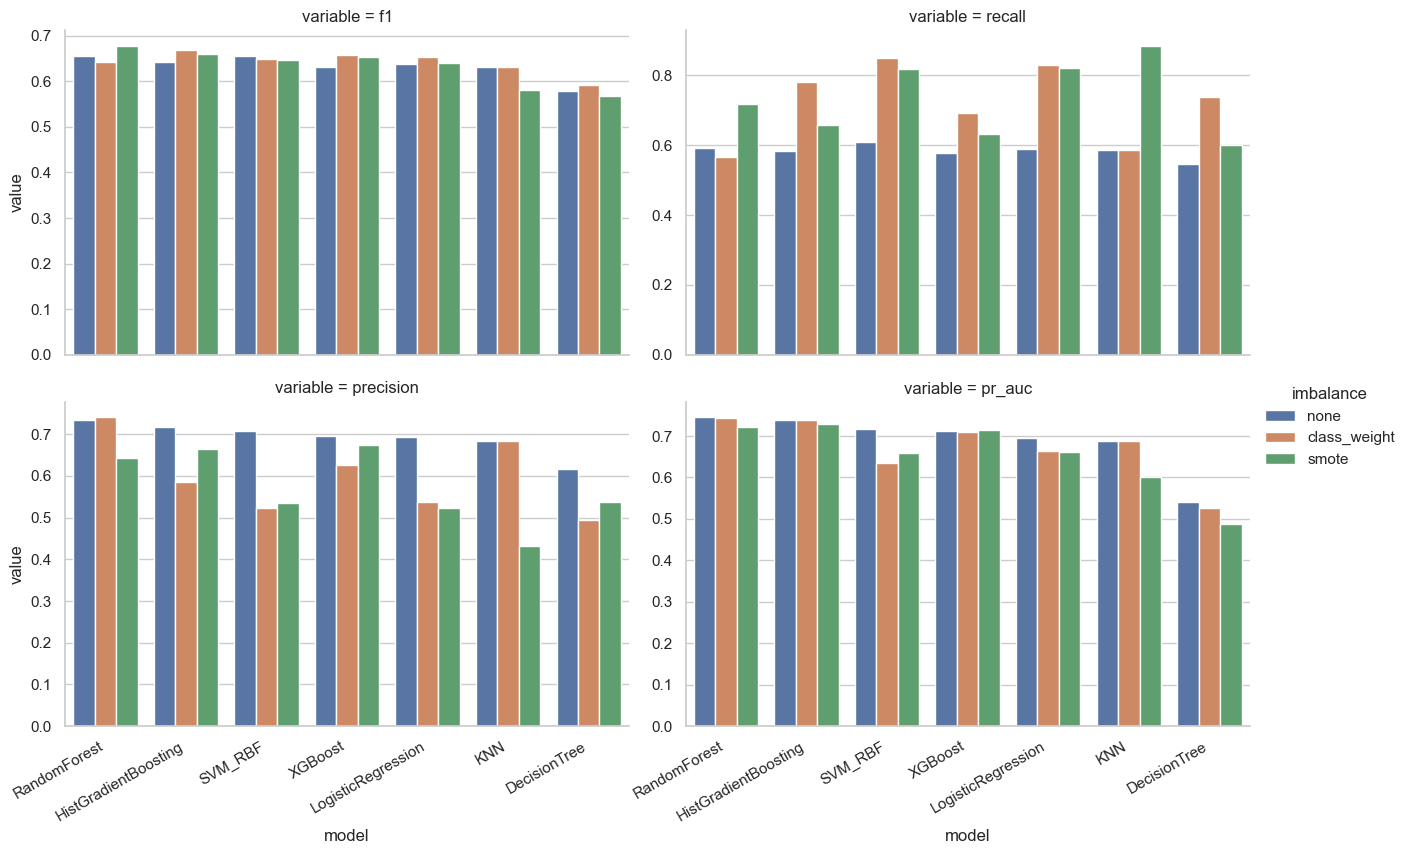

[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\figures\baseline_model_comparison.png


In [5]:
melt = baseline.melt(id_vars=["model", "imbalance"], value_vars=["f1", "recall", "precision", "pr_auc"])
g = sns.catplot(data=melt, x="model", y="value", hue="imbalance", col="variable", kind="bar",
                col_wrap=2, height=4, aspect=1.6, sharey=False)
for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
save_fig(g.figure, "baseline_model_comparison")

## 3. Individual model analysis

Each member analyses their assigned model(s) from the shared comparison above.

### Member 1 - Logistic Regression & Decision Tree

In [6]:
mine = baseline[baseline["model"].isin(["LogisticRegression", "DecisionTree"])]
display(mine[["model", "imbalance", "f1", "recall", "precision", "pr_auc", "fit_time_s"]].round(4))
# TODO (Member 1): write 3-4 sentences here on why these two performed as they did,
# how imbalance handling changed their results, and how they compare to the top model.

,model,imbalance,f1,recall,precision,pr_auc,fit_time_s
10,LogisticRegression,none,0.6368,0.5891,0.6937,0.6942,0.4724
13,LogisticRegression,class_weight,0.6522,0.8296,0.5375,0.6638,0.4053
14,LogisticRegression,smote,0.6391,0.8218,0.5232,0.6604,1.0483
18,DecisionTree,none,0.5786,0.5459,0.6162,0.5404,0.4428
19,DecisionTree,class_weight,0.5912,0.7366,0.4939,0.5256,0.3881
20,DecisionTree,smote,0.5676,0.6009,0.5384,0.4877,1.2603


### Member 2 - HistGradientBoosting & XGBoost

In [7]:
mine = baseline[baseline["model"].isin(["HistGradientBoosting", "XGBoost"])]
display(mine[["model", "imbalance", "f1", "recall", "precision", "pr_auc", "fit_time_s"]].round(4))
# TODO (Member 2): write 3-4 sentences here.

,model,imbalance,f1,recall,precision,pr_auc,fit_time_s
2,HistGradientBoosting,none,0.6423,0.5819,0.7174,0.7393,1.9196
3,HistGradientBoosting,class_weight,0.6691,0.7798,0.5861,0.7379,2.0651
4,HistGradientBoosting,smote,0.6602,0.6579,0.6635,0.7295,3.6067
7,XGBoost,smote,0.6520,0.6310,0.6747,0.7146,3.1943
8,XGBoost,none,0.6318,0.5786,0.6965,0.7125,1.6382
9,XGBoost,class_weight,0.6562,0.6913,0.6249,0.7107,1.3950


### Member 3 - SVM & KNN

In [8]:
mine = baseline[baseline["model"].isin(["SVM_RBF", "KNN"])]
display(mine[["model", "imbalance", "f1", "recall", "precision", "pr_auc", "fit_time_s"]].round(4))
# TODO (Member 3): write 3-4 sentences here.

,model,imbalance,f1,recall,precision,pr_auc,fit_time_s
6,SVM_RBF,none,0.6549,0.6094,0.7082,0.7176,3.2067
11,KNN,none,0.6314,0.5872,0.6836,0.6867,0.2226
12,KNN,class_weight,0.6314,0.5872,0.6836,0.6867,0.2072
15,SVM_RBF,smote,0.6456,0.8172,0.5340,0.6598,13.3100
16,SVM_RBF,class_weight,0.6481,0.8506,0.5238,0.6355,4.9151
17,KNN,smote,0.5795,0.8847,0.4310,0.6017,0.3746


### Member 4 - Random Forest

In [9]:
mine = baseline[baseline["model"] == "RandomForest"]
display(mine[["model", "imbalance", "f1", "recall", "precision", "pr_auc", "fit_time_s"]].round(4))
# TODO (Member 4): write 3-4 sentences here.

,model,imbalance,f1,recall,precision,pr_auc,fit_time_s
0,RandomForest,none,0.6542,0.5911,0.7328,0.7458,7.3469
1,RandomForest,class_weight,0.6413,0.5655,0.7411,0.7422,7.2282
5,RandomForest,smote,0.6777,0.7169,0.6430,0.7212,15.2456


## 4. Summary
Record which models/strategies look strongest here — this feeds directly into
`04_model_optimization.ipynb`, where the promising models get tuned.